In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [52]:
df = pd.read_csv("/content/drive/MyDrive/Student-Score-Predictor/data/raw/Expanded_data_with_more_features.csv")
df.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


# Student Performance Prediction - EDA

Goal: Understand the dataset before building any ML model.

In [53]:
df.shape

(30641, 15)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [55]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [56]:
df.isnull().sum()

,0
Unnamed: 0,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,1572


In [57]:
df["Unnamed: 0"].head(10)

,Unnamed: 0
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7
8,8
9,9


In [58]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [59]:
df.columns

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings',
       'TransportMeans', 'WklyStudyHours', 'MathScore', 'ReadingScore',
       'WritingScore'],
      dtype='object')

In [60]:
(df.isnull().sum() / len(df)) * 100

,0
Gender,0.000000
EthnicGroup,6.005026
ParentEduc,6.021344
LunchType,0.000000
TestPrep,5.972390
ParentMaritalStatus,3.883685
PracticeSport,2.059332
IsFirstChild,2.950295
NrSiblings,5.130381
TransportMeans,10.228126


In [61]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild',
       'TransportMeans', 'WklyStudyHours'],
      dtype='object')

In [62]:
numeric_cols = df.select_dtypes(exclude='object').columns
numeric_cols

Index(['NrSiblings', 'MathScore', 'ReadingScore', 'WritingScore'], dtype='object')

In [63]:
categorical_cols_to_fill = [
    "EthnicGroup",
    "ParentEduc",
    "LunchType",
    "TestPrep",
    "ParentMaritalStatus",
    "PracticeSport",
    "TransportMeans"
]

for col in categorical_cols_to_fill:
    df[col] = df[col].fillna("Unknown")

In [64]:
df.isnull().sum()

,0
Gender,0
EthnicGroup,0
ParentEduc,0
LunchType,0
TestPrep,0
ParentMaritalStatus,0
PracticeSport,0
IsFirstChild,904
NrSiblings,1572
TransportMeans,0


In [65]:
df['NrSiblings'] = df['NrSiblings'].fillna(df['NrSiblings'].median())

In [66]:
df["IsFirstChild"] = df["IsFirstChild"].replace("None", np.nan)
df["IsFirstChild"].mode()

,IsFirstChild
0,yes


In [67]:
df["IsFirstChild"] = df["IsFirstChild"].fillna(df["IsFirstChild"].mode()[0])

In [68]:
df.isnull().sum()

,0
Gender,0
EthnicGroup,0
ParentEduc,0
LunchType,0
TestPrep,0
ParentMaritalStatus,0
PracticeSport,0
IsFirstChild,0
NrSiblings,0
TransportMeans,0


In [70]:
df.dropna(subset=["WklyStudyHours"],inplace = True)

In [71]:
df.isnull().sum()

,0
Gender,0
EthnicGroup,0
ParentEduc,0
LunchType,0
TestPrep,0
ParentMaritalStatus,0
PracticeSport,0
IsFirstChild,0
NrSiblings,0
TransportMeans,0


<function matplotlib.pyplot.show(close=None, block=None)>

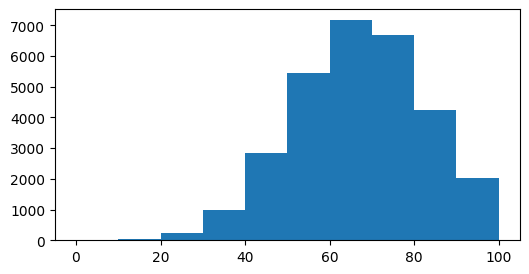

In [72]:
plt.figure(figsize=(6,3))
plt.hist(df['MathScore'])
plt.show

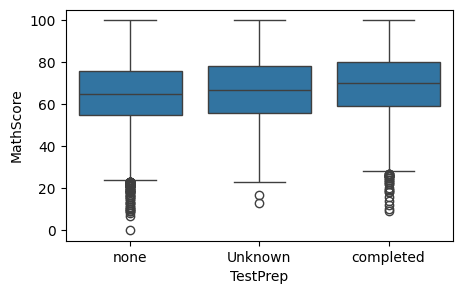

In [73]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df["TestPrep"], y=df["MathScore"])
plt.show()

In [74]:
df[numeric_cols].corr()

,NrSiblings,MathScore,ReadingScore,WritingScore
NrSiblings,1.000000,-0.000767,-0.000059,-0.001600
MathScore,-0.000767,1.000000,0.817733,0.806968
ReadingScore,-0.000059,0.817733,1.000000,0.952467
WritingScore,-0.001600,0.806968,0.952467,1.000000


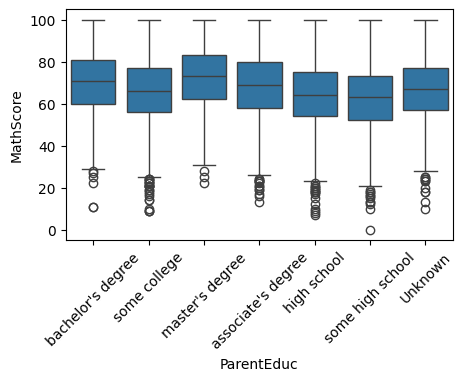

In [76]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df["ParentEduc"], y=df["MathScore"])
plt.xticks(rotation=45)
plt.show()

In [77]:
df['WklyStudyHours'].value_counts()

,count
WklyStudyHours,
5 - 10,16246
< 5,8238
> 10,5202


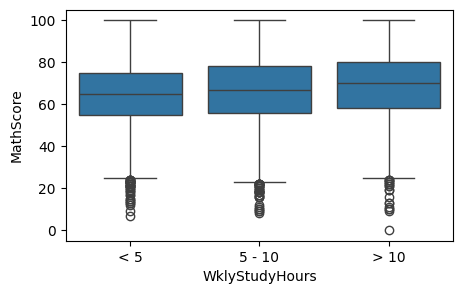

In [78]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df["WklyStudyHours"], y=df["MathScore"])
plt.show()

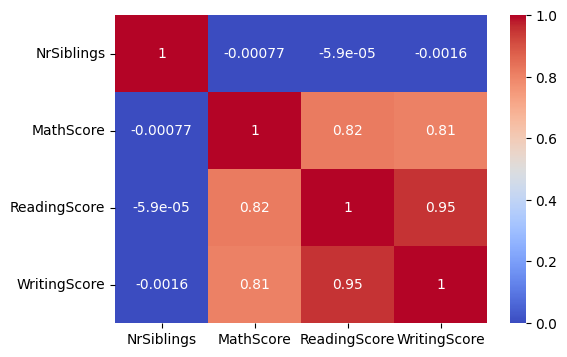

In [79]:
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [84]:
df.to_csv(
    "/content/drive/MyDrive/Student-Score-Predictor/data/processed/processed_data.csv",
    index=False
)